# 04 -- PyTorch & TensorFlow

Same problem as Notebook 03 -- predict `rating` (1-5 spottability) from the
same 13 engineered features -- but swapping Ridge/RandomForest/
GradientBoosting for a small neural net, built once in PyTorch and once in
Keras/TensorFlow.

**Expectation going in, stated honestly:** with only 228 labeled rows, a
neural net is likely to lose to GradientBoosting (MAE 1.02 in Notebook 03's
nested CV), not beat it. That's not a wasted module -- watching it happen,
and seeing *why* (via the loss curves below), is the point. Tree ensembles
tend to win on small tabular datasets; neural nets need much more data (or
much more regularization) to earn their extra flexibility. This notebook
runs inside the Docker container (`docker compose up ml`), not the native
`.venv` -- that's where torch/tensorflow live.

This notebook reuses Notebook 03's exact train/test split (same
`random_state`, same `stratify=y`) so the comparison is apples-to-apples.

**2026-08-30 note:** the hardcoded comparison numbers in this notebook (GradientBoosting MAE 1.189, etc.) are from Notebook 03's satellite-imagery-based labeling pass, since replaced by FAA VFR sectional chart labeling (see data/labels/chart_picks.csv). They'll need refreshing once the route is relabeled and Notebook 03 is rerun -- rerun this notebook after that to get honest numbers.

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path("/workspace")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## Step 1 -- Load the same modeling table as Notebook 03

Identical feature set and `name_uniqueness` NaN-fill (unnamed candidates ->
0.0) as Notebook 03's Step 4 -- see that notebook for why.

In [2]:
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features_c81_kdlh.parquet"
LABELS_PATH = PROJECT_ROOT / "data" / "labels" / "spottability_ratings.csv"

from vfr import pipeline

# The labelled table and the split every trainer in this project uses --
# vfr.pipeline.labeled_split, the one retrain() and the candidate models
# call, so these numbers are comparable with the Dev console's. It reads
# the chart picks as well as the older ratings file, fills a missing
# name_uniqueness, and knows which feature columns there are.
split = pipeline.labeled_split(FEATURES_PATH, LABELS_PATH)
labeled_df, FEATURE_COLS = split.labeled, split.feature_cols
X = labeled_df[FEATURE_COLS]
y = labeled_df["rating"].astype(float)

print(f"{len(labeled_df)} labeled candidates, {len(FEATURE_COLS)} features")

205 labeled candidates, 12 features


## Step 2 -- Split and scale

Same 80/20 held-out split as Notebook 03 (`random_state=42`,
`stratify=y`), so `X_test`/`y_test` here is the *identical* set of rows
Notebook 03 scored GradientBoosting against. The training portion gets a
further 80/20 split for early-stopping validation -- neural nets need a
validation set to know when to stop, which the tree models didn't.

**Scaling is new here.** Ridge/RandomForest/GradientBoosting didn't need
it (trees split on raw values regardless of scale; Ridge's regularization
is scale-sensitive but 13 features on comparable-ish scales didn't matter
much). Neural nets are sensitive to input scale -- an unscaled
`along_track_nm` (0-300+) next to `within_preferred_corridor` (0/1) would
dominate early gradients. `StandardScaler` fit on the training data only,
applied to val/test -- fitting on the full dataset would leak test-set
statistics into training.

In [3]:
# The holdout retrain() scores on (pipeline.holdout_split); a slice of
# the rest is the validation set early stopping watches.
X_train, X_test, y_train, y_test = split.X_train, split.X_test, split.y_train, split.y_test
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

scaler = StandardScaler()
X_train_fit_s = scaler.fit_transform(X_train_fit)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"train_fit: {len(X_train_fit)}, val: {len(X_val)}, test: {len(X_test)}")

train_fit: 130, val: 33, test: 42


## Step 3 -- PyTorch MLP

A small network on purpose: 13 -> 32 -> 16 -> 1 with dropout between
layers. Bigger would just overfit faster on 145 training rows. Adam
optimizer with weight decay (L2) on top of dropout -- two regularizers,
still likely not enough to catch up to GradientBoosting, which is the
expected result, not a bug to chase.

Training tracks train/val loss per epoch and stops (`patience=20`) once
val loss stops improving, restoring the best-seen weights -- the neural-net
equivalent of Notebook 03's cross-validated hyperparameter tuning: letting
the data decide when to stop rather than eyeballing an epoch count.

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)


class SpottabilityMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32)


train_ds = TensorDataset(to_tensor(X_train_fit_s), to_tensor(y_train_fit.to_numpy()))
train_loader = DataLoader(
    train_ds, batch_size=32, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)

torch_model = SpottabilityMLP(len(FEATURE_COLS))
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

X_val_t, y_val_t = to_tensor(X_val_s), to_tensor(y_val.to_numpy())

torch_train_losses, torch_val_losses = [], []
best_val, best_state, patience, patience_left = float("inf"), None, 20, 20

for epoch in range(300):
    torch_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = torch_model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_ds)

    torch_model.eval()
    with torch.no_grad():
        val_loss = loss_fn(torch_model(X_val_t), y_val_t).item()

    torch_train_losses.append(epoch_loss)
    torch_val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in torch_model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f"Early stopping at epoch {epoch}")
            break

torch_model.load_state_dict(best_state)
torch_model.eval()


Early stopping at epoch 64


SpottabilityMLP(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

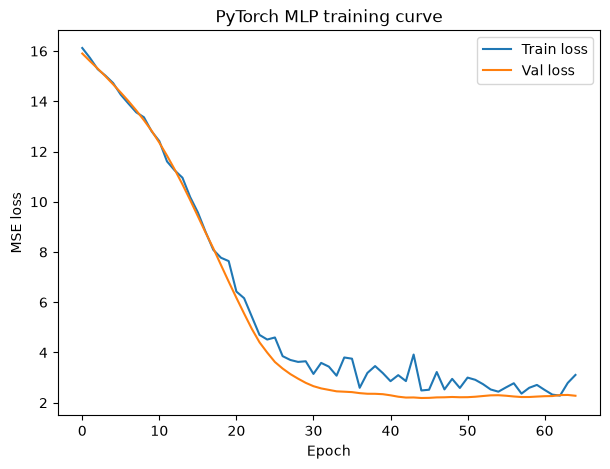

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(torch_train_losses, label="Train loss")
ax.plot(torch_val_losses, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("PyTorch MLP training curve")
ax.legend()
plt.show()


In [6]:
with torch.no_grad():
    y_pred_torch = torch_model(to_tensor(X_test_s)).numpy()

torch_mae = mean_absolute_error(y_test, y_pred_torch)
torch_rmse = mean_squared_error(y_test, y_pred_torch) ** 0.5
torch_r2 = r2_score(y_test, y_pred_torch)

print(f"PyTorch held-out -- MAE: {torch_mae:.3f}  RMSE: {torch_rmse:.3f}  R^2: {torch_r2:.3f}")


PyTorch held-out -- MAE: 1.148  RMSE: 1.374  R^2: -0.039


## Step 4 -- TensorFlow / Keras MLP

Identical architecture (13 -> 32 -> 16 -> 1, same dropout), same data,
same early-stopping patience -- the point is comparing *framework syntax
and workflow*, not giving one architecture an advantage. Keras's
`EarlyStopping(restore_best_weights=True)` callback does the same job as
the manual best-state tracking in the PyTorch loop above, just built in.

In [7]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(RANDOM_STATE)

keras_model = keras.Sequential([
    keras.layers.Input(shape=(len(FEATURE_COLS),)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1),
])
keras_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
history = keras_model.fit(
    X_train_fit_s, y_train_fit.to_numpy(),
    validation_data=(X_val_s, y_val.to_numpy()),
    epochs=300, batch_size=32, callbacks=[early_stop], verbose=0,
)
print(f"Stopped after {len(history.history['loss'])} epochs")


I0000 00:00:1790233893.998104     435 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790233894.059137     435 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790233895.727304     435 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1790233895.966971     435 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Stopped after 77 epochs


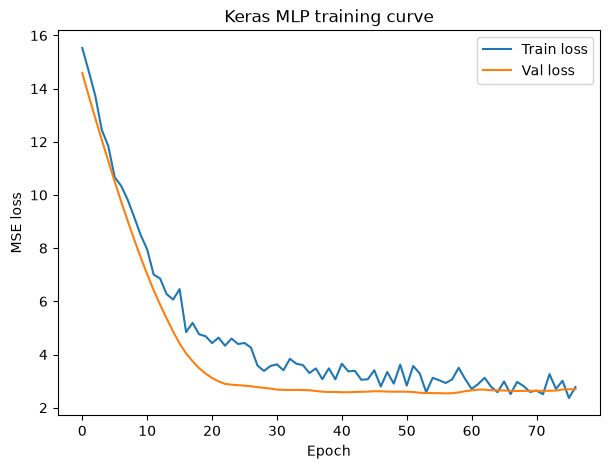

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history["loss"], label="Train loss")
ax.plot(history.history["val_loss"], label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Keras MLP training curve")
ax.legend()
plt.show()


In [9]:
y_pred_keras = keras_model.predict(X_test_s, verbose=0).flatten()

keras_mae = mean_absolute_error(y_test, y_pred_keras)
keras_rmse = mean_squared_error(y_test, y_pred_keras) ** 0.5
keras_r2 = r2_score(y_test, y_pred_keras)

print(f"Keras held-out -- MAE: {keras_mae:.3f}  RMSE: {keras_rmse:.3f}  R^2: {keras_r2:.3f}")


Keras held-out -- MAE: 1.147  RMSE: 1.387  R^2: -0.059


## Step 5 -- Comparison

Same held-out 46-row test set for all four models. Notebook 03's numbers
are carried over here rather than recomputed, so this table is the actual
payoff of reusing that exact split in Step 2.

Read this with Notebook 03's Step 12 lesson in mind: a single 46-row
holdout is noisy (that's *why* Notebook 03 added nested CV). The gap
between GradientBoosting and the neural nets here is large enough (MAE
~1.19 vs ~1.5) that it's very unlikely to be pure holdout noise -- but
don't over-read small differences between PyTorch and Keras themselves on
one split; those two are close enough that swapping the random seed could
flip which one "wins."

In [10]:
current_metrics_path = PROJECT_ROOT / "data" / "models" / "current" / "metrics.json"
if current_metrics_path.exists():
    baseline_metrics = json.loads(current_metrics_path.read_text())
    baseline_row = {
        "model": f"{baseline_metrics['model_type']} (promoted, pipeline.retrain)",
        "MAE": baseline_metrics["held_out_mae"],
        "RMSE": baseline_metrics["held_out_rmse"],
        "R2": baseline_metrics["held_out_r2"],
    }
else:
    print(
        "No promoted model yet at data/models/current/metrics.json -- run "
        "`docker compose run --rm pipeline-training retrain` (+ evaluate + promote) for a live "
        "baseline. Falling back to Notebook 03's last hand-recorded satellite-labeled "
        "run (stale -- see project memory on the labeling methodology change)."
    )
    baseline_row = {
        "model": "GradientBoosting (Notebook 03, satellite-labeled, stale)",
        "MAE": 1.189, "RMSE": 1.560, "R2": -0.109,
    }

comparison = pd.DataFrame([
    baseline_row,
    {"model": "PyTorch MLP", "MAE": torch_mae, "RMSE": torch_rmse, "R2": torch_r2},
    {"model": "Keras MLP", "MAE": keras_mae, "RMSE": keras_rmse, "R2": keras_r2},
]).set_index("model")

comparison

,MAE,RMSE,R2
model,,,
"RandomForest (promoted, pipeline.retrain)",0.872655,1.076429,0.288568
PyTorch MLP,1.147715,1.373879,-0.039210
Keras MLP,1.146896,1.387073,-0.059265


In [11]:
# Persisted so Notebook 06 can read these dynamically instead of hardcoding
# them as literals (the same staleness problem the baseline-comparison cell
# above was fixed for -- see project memory on the labeling methodology change).
benchmarks_path = PROJECT_ROOT / "data" / "models" / "benchmarks" / "04_pytorch_tensorflow.json"
benchmarks_path.parent.mkdir(parents=True, exist_ok=True)
benchmarks_path.write_text(json.dumps({
    "pytorch_mlp": {"MAE": torch_mae, "RMSE": torch_rmse, "R2": torch_r2},
    "keras_mlp": {"MAE": keras_mae, "RMSE": keras_rmse, "R2": keras_r2},
}, indent=2))
print(f"Saved to {benchmarks_path}")

Saved to /workspace/data/models/benchmarks/04_pytorch_tensorflow.json
